! like Brilliant, make a program that responds live to the user's drawing by changing the output probs

In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

In [2]:
model_path = "model.pth"

checkpoint = torch.load(model_path, map_location="cpu")


print(f"{'Layer Name':<20} | {'Shape':<20} | {'Size (MB)'}")
print("-" * 60)

total_model_size = 0

for name, tensor in checkpoint.items():
    # 1. Total elements in this tensor
    num_elements = tensor.numel()
    
    # 2. Bytes per element (handles float32, float16, etc. automatically)
    bytes_per_element = tensor.element_size()
    
    # 3. Calculate size in MB
    size_mb = (num_elements * bytes_per_element) / (1024 * 1024)
    total_model_size += size_mb
    
    # Format shape for printing
    shape_str = str(list(tensor.shape))
    
    print(f"{name:<20} | {shape_str:<20} | {size_mb:.4f} MB")

print("-" * 60)
print(f"Total Model Size: {total_model_size:.4f} MB")

Layer Name           | Shape                | Size (MB)
------------------------------------------------------------
fc1.weight           | [128, 784]           | 0.3828 MB
fc1.bias             | [128]                | 0.0005 MB
fc2.weight           | [10, 128]            | 0.0049 MB
fc2.bias             | [10]                 | 0.0000 MB
------------------------------------------------------------
Total Model Size: 0.3882 MB


In [3]:
# 1. Define the EXACT same architecture
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=10):
        super().__init__()
        # Use the exact variable names (keys) the model is looking for:
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [4]:

# 2. Load the model scaffold
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP().to(device)

# Load state_dict (the weights)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval() # Set to evaluation mode!
print(f"Model weights loaded from {model_path}")

Model weights loaded from model.pth


In [5]:
def predict_custom_image(image_path: str):
    
    # 1. Preprocess the custom image
    # Open image, convert to Grayscale ('L')
    img = Image.open(image_path).convert('L')

    # Resize to 28x28 and convert to Tensor
    transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
    ])
    
    img_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension: [1, 1, 28, 28]

    # 2. Inference
    with torch.no_grad():
        output = model(img_tensor)
        # Apply Softmax to get probabilities 
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)


    print(f"Predicted Digit: {predicted.item()}")
    print(f"Confidence: {confidence.item()*100:.2f}%")
    
    # Visualize
    plt.imshow(img, cmap='gray')


Predicted Digit: 6
Confidence: 28.63%


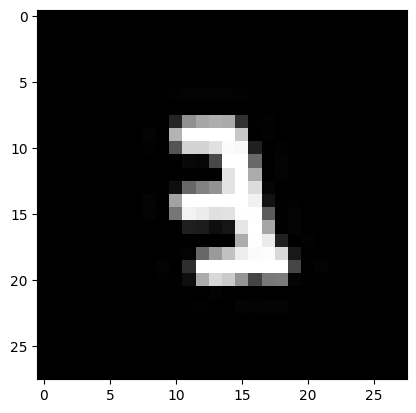

In [8]:
predict_custom_image("digit_5.png")


In [7]:
from torchviz import make_dot

# Dummy input
x = torch.randn(1, 1, 28, 28).to(device)
# Forward pass
y = model(x)

device = next(model.parameters()).device
print(device)
# Generate the graph visualization
make_dot(y, params=dict(model.named_parameters())).render("mnist_graph", format="png")


cuda:0


'mnist_graph.png'